# Environment Setup & Data Loading

Initial setup for the experiment, including dependencies, configuration, and dataset preparation.

---

## Environment Setup

- Google Drive is mounted to access dataset  
- Required libraries for **video processing, ML, and deep learning** are imported  
- Reproducibility ensured using fixed random seeds  
- GPU availability is checked for accelerated computation  

---

## Configuration

- Image size, number of frames, batch size, and epochs are defined  
- Dataset root directory is specified from Google Drive  

---

## Data Loading

- Video file paths are collected from dataset directories  
- Labels are inferred from folder names  
- A structured DataFrame is created with:
  - **video_path**
  - **label**

---

## Purpose

Establishes the working environment and organizes raw video data into a structured format for further processing.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Root folder in Google Drive
DATA_ROOT = "/content/drive/MyDrive/NLP Dataset"

# Fast settings for quick results
IMG_SIZE = 160
NUM_FRAMES = 6
EPOCHS = 2
BATCH_SIZE = 8

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [ ]:
!pip -q install opencv-python-headless scikit-learn tqdm

In [ ]:
video_paths = list(Path(DATA_ROOT).rglob("*.mp4"))

records = []
for vp in video_paths:
    # sentence folder = parent of the video file
    label = vp.parent.name.strip()
    records.append({
        "video_path": str(vp),
        "label": label
    })

df = pd.DataFrame(records)

print("Total videos found:", len(df))
print("Total classes found:", df["label"].nunique())
print(df.head())

Total videos found: 2410
Total classes found: 188
                                          video_path           label
0  /content/drive/MyDrive/NLP Dataset/Group_14/20...  do me a favour
1  /content/drive/MyDrive/NLP Dataset/Group_14/20...  do me a favour
2  /content/drive/MyDrive/NLP Dataset/Group_14/20...  do me a favour
3  /content/drive/MyDrive/NLP Dataset/Group_14/20...  do me a favour
4  /content/drive/MyDrive/NLP Dataset/Group_14/20...  do me a favour


# Data Preparation & Feature Extraction

This step prepares the dataset and converts videos into feature sequences.

---

## Data Processing

- Missing entries are removed  
- Labels are encoded into numerical form  
- Dataset is split into **training** and **validation** sets (stratified when possible)  

---

## Feature Extraction

- **MobileNetV2 (pretrained on ImageNet)** is used as a frozen backbone  
- Videos are converted into a fixed number of frames  
- Each frame is preprocessed and passed through the network  
- Output: sequence of feature vectors per video  

---

## Output

- **X_train / X_val** → feature sequences *(num_samples, num_frames, feature_dim)*  
- **y_train / y_val** → corresponding labels  

---

## Purpose

Transforms raw video data into structured numerical features suitable for sequence models like LSTM and BiLSTM.

In [ ]:
# Remove missing entries if any
df = df.dropna().reset_index(drop=True)

# Label encoding
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

print("Classes:", len(label_encoder.classes_))

# Split
label_counts = df["label"].value_counts()
if label_counts.min() >= 2 and df["label"].nunique() > 1:
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df["label"]
    )
else:
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42
    )

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train videos:", len(train_df))
print("Val videos:", len(val_df))

Classes: 188
Train videos: 1928
Val videos: 482


In [ ]:
# Frozen MobileNetV2 for frame-level feature extraction
cnn_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
cnn_base.trainable = False

print("MobileNetV2 feature extractor ready.")
print("Feature vector size:", cnn_base.output_shape[-1])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 feature extractor ready.
Feature vector size: 1280


In [ ]:
def sample_frames_from_video(video_path, num_frames=NUM_FRAMES, img_size=IMG_SIZE):
    """
    Returns a fixed number of evenly sampled frames from one video.
    Output shape: (num_frames, img_size, img_size, 3)
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return np.zeros((num_frames, img_size, img_size, 3), dtype=np.float32)

    frame_indices = np.linspace(0, max(total_frames - 1, 0), num_frames).astype(int)

    frames = []
    last_frame = np.zeros((img_size, img_size, 3), dtype=np.float32)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()

        if not ret or frame is None:
            frame = last_frame
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frame = preprocess_input(frame.astype(np.float32))
            last_frame = frame

        frames.append(frame)

    cap.release()
    return np.array(frames, dtype=np.float32)


def extract_video_features(video_path):
    """
    Converts one video into a sequence of MobileNetV2 features.
    Output shape: (num_frames, feature_dim)
    """
    frames = sample_frames_from_video(video_path)
    features = cnn_base.predict(frames, verbose=0)
    return features

In [ ]:
X_train, y_train = [], []
X_val, y_val = [], []

print("Extracting training features...")
for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    feats = extract_video_features(row["video_path"])
    X_train.append(feats)
    y_train.append(row["label_id"])

print("Extracting validation features...")
for _, row in tqdm(val_df.iterrows(), total=len(val_df)):
    feats = extract_video_features(row["video_path"])
    X_val.append(feats)
    y_val.append(row["label_id"])

X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int32)
y_val = np.array(y_val, dtype=np.int32)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

gc.collect()

Extracting training features...


100%|██████████| 1928/1928 [1:25:18<00:00,  2.66s/it]


Extracting validation features...


100%|██████████| 482/482 [20:36<00:00,  2.57s/it]


X_train shape: (1928, 6, 1280)
X_val shape: (482, 6, 1280)
y_train shape: (1928,)
y_val shape: (482,)


51668

In [ ]:
np.save("/content/drive/MyDrive/X_train.npy", X_train)
np.save("/content/drive/MyDrive/X_val.npy", X_val)
np.save("/content/drive/MyDrive/y_train.npy", y_train)
np.save("/content/drive/MyDrive/y_val.npy", y_val)

np.save("/content/drive/MyDrive/label_classes.npy", label_encoder.classes_)

print("All features saved to Google Drive.")

All features saved to Google Drive.


# LSTM Baseline Model

A foundational architecture for **sequence classification**, designed to capture temporal dependencies with minimal complexity.

---

## Architecture

- **Input Layer**  
  Sequence input of shape *(NUM_FRAMES, feature_dim)*  

- **LSTM (128 units)**  
  Learns high-level temporal patterns across the sequence  

- **Dropout (0.3)**  
  Mitigates overfitting and improves generalization  

- **LSTM (64 units)**  
  Refines and compresses learned representations  

- **Dropout (0.3)**  

- **Dense (Softmax Output)**  
  Produces probability distribution over target classes  

---

## Training Configuration

- **Optimizer**  Adam *(learning rate = 1 × 10⁻³)*  
- **Loss Function** Sparse Categorical Crossentropy  
- **Evaluation Metric** Accuracy  

---

## Design Intent

This model serves as a **baseline benchmark**, offering a balance between simplicity and performance.  
It establishes a reference point for evaluating more advanced architectures such as **Bidirectional LSTM** and **Attention-based models**.

In [ ]:
num_classes = len(label_encoder.classes_)
feature_dim = X_train.shape[-1]

model = Sequential([
    Input(shape=(NUM_FRAMES, feature_dim)),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 6, 128)         │       721,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 188)            │        12,220 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 783,036 (2.99 MB)

 Trainable params: 783,036 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/2
241/241 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.0124 - loss: 5.1534 - val_accuracy: 0.0228 - val_loss: 4.9313
Epoch 2/2
241/241 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0358 - loss: 4.7145 - val_accuracy: 0.0747 - val_loss: 4.2565


In [ ]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation loss: {val_loss:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Validation loss: 4.2565
Validation accuracy: 0.0747

Classification Report:
                                       precision    recall  f1-score   support

                       Can I help you       0.00      0.00      0.00         1
           Can you repeat that please       0.00      0.00      0.00         2
                       Comb your hair       0.00      0.00      0.00         2
                      Congratulations       0.00      0.00      0.00         2
         Could you please talk slower       0.00      0.00      0.00         2
                       Do me a favour       0.00      0.00      0.00         1
            He is going into the room       0.00      0.00      0.00         4
                     He is on the way       0.00      0.00      0.00         1
                  He she is my friend       0.00      0.00      0.00         1
             He would be coming today       0.00      0.00      0.00         2
                              Help me       0.00      

In [ ]:
sample_idx = 0
sample_path = val_df.iloc[sample_idx]["video_path"]
true_label = val_df.iloc[sample_idx]["label"]

sample_features = extract_video_features(sample_path)
sample_features = np.expand_dims(sample_features, axis=0)

pred_id = np.argmax(model.predict(sample_features, verbose=0), axis=1)[0]
pred_label = label_encoder.inverse_transform([pred_id])[0]

print("Video:", sample_path)
print("True label:", true_label)
print("Predicted label:", pred_label)

Video: /content/drive/MyDrive/NLP Dataset/Group_03/2022IMT035/i am hungry/v3.mp4
True label: i am hungry
Predicted label: I am feeling cold


In [ ]:
model.save("/content/drive/MyDrive/csl_mobilenet_lstm_model.keras")

classes_path = "/content/drive/MyDrive/csl_label_classes.npy"
np.save(classes_path, label_encoder.classes_)

print("Model saved to Drive.")
print("Classes saved to Drive.")

Model saved to Drive.
Classes saved to Drive.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import time
import numpy as np

# Predict on validation set
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# Basic accuracy
acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_val, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

Validation Accuracy : 0.0747
Precision           : 0.0282
Recall              : 0.0747
F1 Score            : 0.0343

Classification Report:
                                       precision    recall  f1-score   support

                       Can I help you       0.00      0.00      0.00         1
           Can you repeat that please       0.00      0.00      0.00         2
                       Comb your hair       0.00      0.00      0.00         2
                      Congratulations       0.00      0.00      0.00         2
         Could you please talk slower       0.00      0.00      0.00         2
                       Do me a favour       0.00      0.00      0.00         1
            He is going into the room       0.00      0.00      0.00         4
                     He is on the way       0.00      0.00      0.00         1
                  He she is my friend       0.00      0.00      0.00         1
             He would be coming today       0.00      0.00      0.00 

# Bidirectional LSTM Model

A sequence classification model leveraging **Bidirectional LSTM layers** to capture context from both past and future timesteps.

---

## Architecture

- **Input Layer**  
  Sequence input of shape *(timesteps, feature_dim)*  

- **Layer Normalization**  
  Stabilizes inputs for efficient training  

- **Bidirectional LSTM (64 units)**  
  Learns forward and backward temporal dependencies  

- **Bidirectional LSTM (32 units)**  
  Refines contextual sequence representation  

- **Global Average Pooling**  
  Aggregates sequence information into a fixed-length vector  

- **Dense Layers (64 → 32 units)**  
  Learns higher-level feature representations  

- **Dropout (0.3 → 0.2)**  
  Reduces overfitting  

- **Dense (Softmax Output)**  
  Outputs class probabilities  

---

## Training Configuration

- **Optimizer**  Adam *(learning rate = 5 × 10⁻⁴)*  
- **Loss Function** Sparse Categorical Crossentropy  
- **Evaluation Metric** Accuracy  

---

## Design Intent

Enhances standard LSTM performance by incorporating **bidirectional context**, enabling a more comprehensive understanding of sequential data.

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GRU, Bidirectional, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

print("Shapes:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("Classes:", len(classes))

Shapes:
X_train: (1928, 6, 1280)
X_val  : (482, 6, 1280)
y_train: (1928,)
y_val  : (482,)
Classes: 188


In [ ]:
timesteps = X_train.shape[1]
feature_dim = X_train.shape[2]
num_classes = len(classes)

inputs = Input(shape=(timesteps, feature_dim))

x = LayerNormalization()(inputs)
x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
x = Bidirectional(LSTM(32, return_sequences=True, dropout=0.2))(x)
x = GlobalAveragePooling1D()(x)

x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)

outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs, name="Simple_BiLSTM_Baseline")

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "Simple_BiLSTM_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 6, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 6, 1280)        │         2,560 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 6, 128)         │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 6, 64)          │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 188)            │         6,204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 744,860 (2.84 MB)

 Trainable params: 744,860 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_path = "/content/drive/MyDrive/simple_bilstm_baseline.keras"
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/20
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3761 - loss: 2.0079
Epoch 1: val_accuracy improved from None to 0.51867, saving model to /content/drive/MyDrive/simple_bilstm_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/simple_bilstm_baseline.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.3838 - loss: 1.9723 - val_accuracy: 0.5187 - val_loss: 1.4642 - learning_rate: 5.0000e-04
Epoch 2/20
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4142 - loss: 1.8602
Epoch 2: val_accuracy improved from 0.51867 to 0.54149, saving model to /content/drive/MyDrive/simple_bilstm_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/simple_bilstm_baseline.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4051 - loss: 1.8683 - val_accuracy: 0.5415 - val_loss: 1.4008 - learning_rate: 5.0000e-04
Epoch 3/20
119/121 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4298 - loss: 1.8279
Epoch 3: val_accuracy improv

In [ ]:
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_val, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=classes, zero_division=0))

Validation Accuracy : 0.7469
Precision           : 0.7493
Recall              : 0.7469
F1 Score            : 0.7236

Classification Report:
                                       precision    recall  f1-score   support

                       Can I help you       0.00      0.00      0.00         1
           Can you repeat that please       1.00      0.50      0.67         2
                       Comb your hair       0.00      0.00      0.00         2
                      Congratulations       0.33      1.00      0.50         2
         Could you please talk slower       1.00      0.50      0.67         2
                       Do me a favour       0.50      1.00      0.67         1
            He is going into the room       1.00      0.25      0.40         4
                     He is on the way       1.00      1.00      1.00         1
                  He she is my friend       1.00      1.00      1.00         1
             He would be coming today       1.00      1.00      1.00 

In [ ]:
model.save("/content/drive/MyDrive/simple_bilstm_baseline_final.keras")
print("Model saved successfully.")

Model saved successfully.


# BiLSTM + Attention Model

An enhanced sequence classification architecture that combines **bidirectional temporal learning** with **self-attention**, enabling the model to focus on the most informative parts of the sequence.

---

## Architecture

- **Input Layer**  
  Sequence input of shape *(timesteps, feature_dim)*  

- **Layer Normalization**  
  Stabilizes input distribution for improved training  

- **TimeDistributed Dense (512 units)**  
  Learns rich feature representations at each timestep  

- **Dropout (0.25)**  

- **Bidirectional LSTM (256 units)**  
  Captures forward and backward temporal dependencies  

- **Bidirectional LSTM (128 units)**  
  Refines contextual sequence understanding  

- **Multi-Head Self-Attention (4 heads)**  
  Enables the model to selectively focus on important timesteps  

- **Residual Connection + Layer Normalization**  
  Preserves learned features and stabilizes deep learning  

- **Global Average Pooling**  
  Converts sequence features into a fixed-length representation  

- **Dense Layers (256 → 128 units, L2 Regularization)**  
  Learns higher-level abstractions with regularization  

- **Dropout (0.4 → 0.3)**  

- **Dense (Softmax Output)**  
  Produces probability distribution over target classes  

---

## Training Configuration

- **Optimizer** Adam *(learning rate = 1 * 10⁻³, gradient clipping applied)*  
- **Loss Function** Sparse Categorical Crossentropy  
- **Evaluation Metric** Accuracy  

---

## Design Intent

This model extends the baseline by integrating **bidirectional sequence modeling** with **attention mechanisms**, allowing it to not only understand temporal relationships but also emphasize the most relevant segments of the input sequence.

In [ ]:
X_train = np.load("/content/drive/MyDrive/X_train.npy")
X_val = np.load("/content/drive/MyDrive/X_val.npy")
y_train = np.load("/content/drive/MyDrive/y_train.npy")
y_val = np.load("/content/drive/MyDrive/y_val.npy")

classes = np.load("/content/drive/MyDrive/label_classes.npy", allow_pickle=True)

print("Loaded shapes:")
print(X_train.shape, X_val.shape)

Loaded shapes:
(1928, 6, 1280) (482, 6, 1280)


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GRU, Bidirectional, LayerNormalization,
    MultiHeadAttention, Add, GlobalAveragePooling1D, SpatialDropout1D,
    TimeDistributed
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("Number of classes:", len(classes))

X_train shape: (1928, 6, 1280)
X_val shape: (482, 6, 1280)
y_train shape: (1928,)
y_val shape: (482,)
Number of classes: 188


In [ ]:
unique_classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=y_train
)
class_weight_dict = dict(zip(unique_classes, class_weights))

print("Class weights ready.")
print(class_weight_dict)

Class weights ready.
{np.int32(0): np.float64(2.5638297872340425), np.int32(1): np.float64(1.2819148936170213), np.int32(2): np.float64(1.2819148936170213), np.int32(3): np.float64(1.2819148936170213), np.int32(4): np.float64(1.2819148936170213), np.int32(5): np.float64(2.5638297872340425), np.int32(6): np.float64(0.6409574468085106), np.int32(7): np.float64(2.5638297872340425), np.int32(8): np.float64(2.5638297872340425), np.int32(9): np.float64(1.2819148936170213), np.int32(10): np.float64(1.2819148936170213), np.int32(11): np.float64(2.5638297872340425), np.int32(12): np.float64(2.5638297872340425), np.int32(13): np.float64(2.5638297872340425), np.int32(14): np.float64(2.5638297872340425), np.int32(15): np.float64(2.5638297872340425), np.int32(16): np.float64(2.5638297872340425), np.int32(17): np.float64(1.2819148936170213), np.int32(18): np.float64(1.2819148936170213), np.int32(19): np.float64(2.5638297872340425), np.int32(20): np.float64(2.5638297872340425), np.int32(21): np.float

In [ ]:
timesteps = X_train.shape[1]
feature_dim = X_train.shape[2]
num_classes = len(classes)

inputs = Input(shape=(timesteps, feature_dim))

x = LayerNormalization()(inputs)
x = TimeDistributed(Dense(512, activation="relu"))(x)
x = Dropout(0.25)(x)

x = Bidirectional(LSTM(256, return_sequences=True, dropout=0.2))(x)
x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2))(x)

attn = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
x = Add()([x, attn])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)
x = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 6, 1280)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 1280)   │      2,560 │ input_layer_2[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 6, 512)    │    655,872 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 6, 512)    │          0 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 6, 512)    │  1,574,912 │ dropout_2[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 6, 256)    │    656,384 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 256)    │    131,712 │ bidirectional_1[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 256)    │          0 │ bidirectional_1[… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │     32,896 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 188)       │     24,252 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,144,892 (12.00 MB)

 Trainable params: 3,144,892 (12.00 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint_path = "/content/drive/MyDrive/best_csl_improved_model.keras"
checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5405 - loss: 1.6931
Epoch 1: val_accuracy improved from None to 0.67220, saving model to /content/drive/MyDrive/best_csl_improved_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_csl_improved_model.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5451 - loss: 1.6435 - val_accuracy: 0.6722 - val_loss: 0.9783 - learning_rate: 5.0000e-04
Epoch 2/20
120/121 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5442 - loss: 1.5832
Epoch 2: val_accuracy improved from 0.67220 to 0.70124, saving model to /content/drive/MyDrive/best_csl_improved_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_csl_improved_model.keras
121/121 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5508 - loss: 1.5329 - val_accuracy: 0.7012 - val_loss: 0.9588 - learning_rate: 5.0000e-04
Epoch 3/20
121/121 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5666 - loss: 1.4989
Epoch 3: val_accuracy di

In [ ]:
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_val, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_val, y_pred, average="weighted", zero_division=0)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Precision           : {prec:.4f}")
print(f"Recall              : {rec:.4f}")
print(f"F1 Score            : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=classes, zero_division=0))

Validation Accuracy : 0.7988
Precision           : 0.8151
Recall              : 0.7988
F1 Score            : 0.7878

Classification Report:
                                       precision    recall  f1-score   support

                       Can I help you       0.00      0.00      0.00         1
           Can you repeat that please       0.33      0.50      0.40         2
                       Comb your hair       1.00      0.50      0.67         2
                      Congratulations       0.50      0.50      0.50         2
         Could you please talk slower       1.00      0.50      0.67         2
                       Do me a favour       0.50      1.00      0.67         1
            He is going into the room       1.00      0.75      0.86         4
                     He is on the way       0.50      1.00      0.67         1
                  He she is my friend       0.50      1.00      0.67         1
             He would be coming today       1.00      0.50      0.67 

In [ ]:
model.save("/content/drive/MyDrive/csl_improved_model_final.keras")
print("Improved model saved successfully.")

Improved model saved successfully.


In [ ]:
sample_idx = 0

sample_true = classes[y_val[sample_idx]]
sample_probs = model.predict(X_val[sample_idx:sample_idx+1], verbose=0)
sample_pred = classes[np.argmax(sample_probs)]

print("True label     :", sample_true)
print("Predicted label:", sample_pred)

True label     : i am hungry
Predicted label: i am feeling cold


# Model Evaluation & Analysis

This section evaluates model performance using multiple perspectives, from overall metrics to detailed prediction insights.

---

## Evaluation Steps

- **Single Sample Prediction**  
  Test the model on an individual input to verify basic behavior.

- **Confusion Matrix (All Classes)**  
  Visualizes overall classification performance across all labels.

- **Confusion Matrix (Top 5 Classes)**  
  Focuses on the most frequent classes for clearer error analysis.

- **Top 5 Confident Correct Predictions**  
  Highlights examples where the model is highly confident and correct.

- **Training Curves (Accuracy & Loss)**  
  Plots training vs validation performance to assess learning behavior and overfitting.

---

## Purpose

Provides both **quantitative metrics** and **qualitative insights** to better understand model strengths, weaknesses, and generalization.

In [ ]:
sample_idx = 0
sample_true = classes[y_val[sample_idx]]

sample_pred_prob = model.predict(X_val[sample_idx:sample_idx+1], verbose=0)
sample_pred = classes[np.argmax(sample_pred_prob)]

print("True label     :", sample_true)
print("Predicted label:", sample_pred)

True label     : i am hungry
Predicted label: i am feeling cold


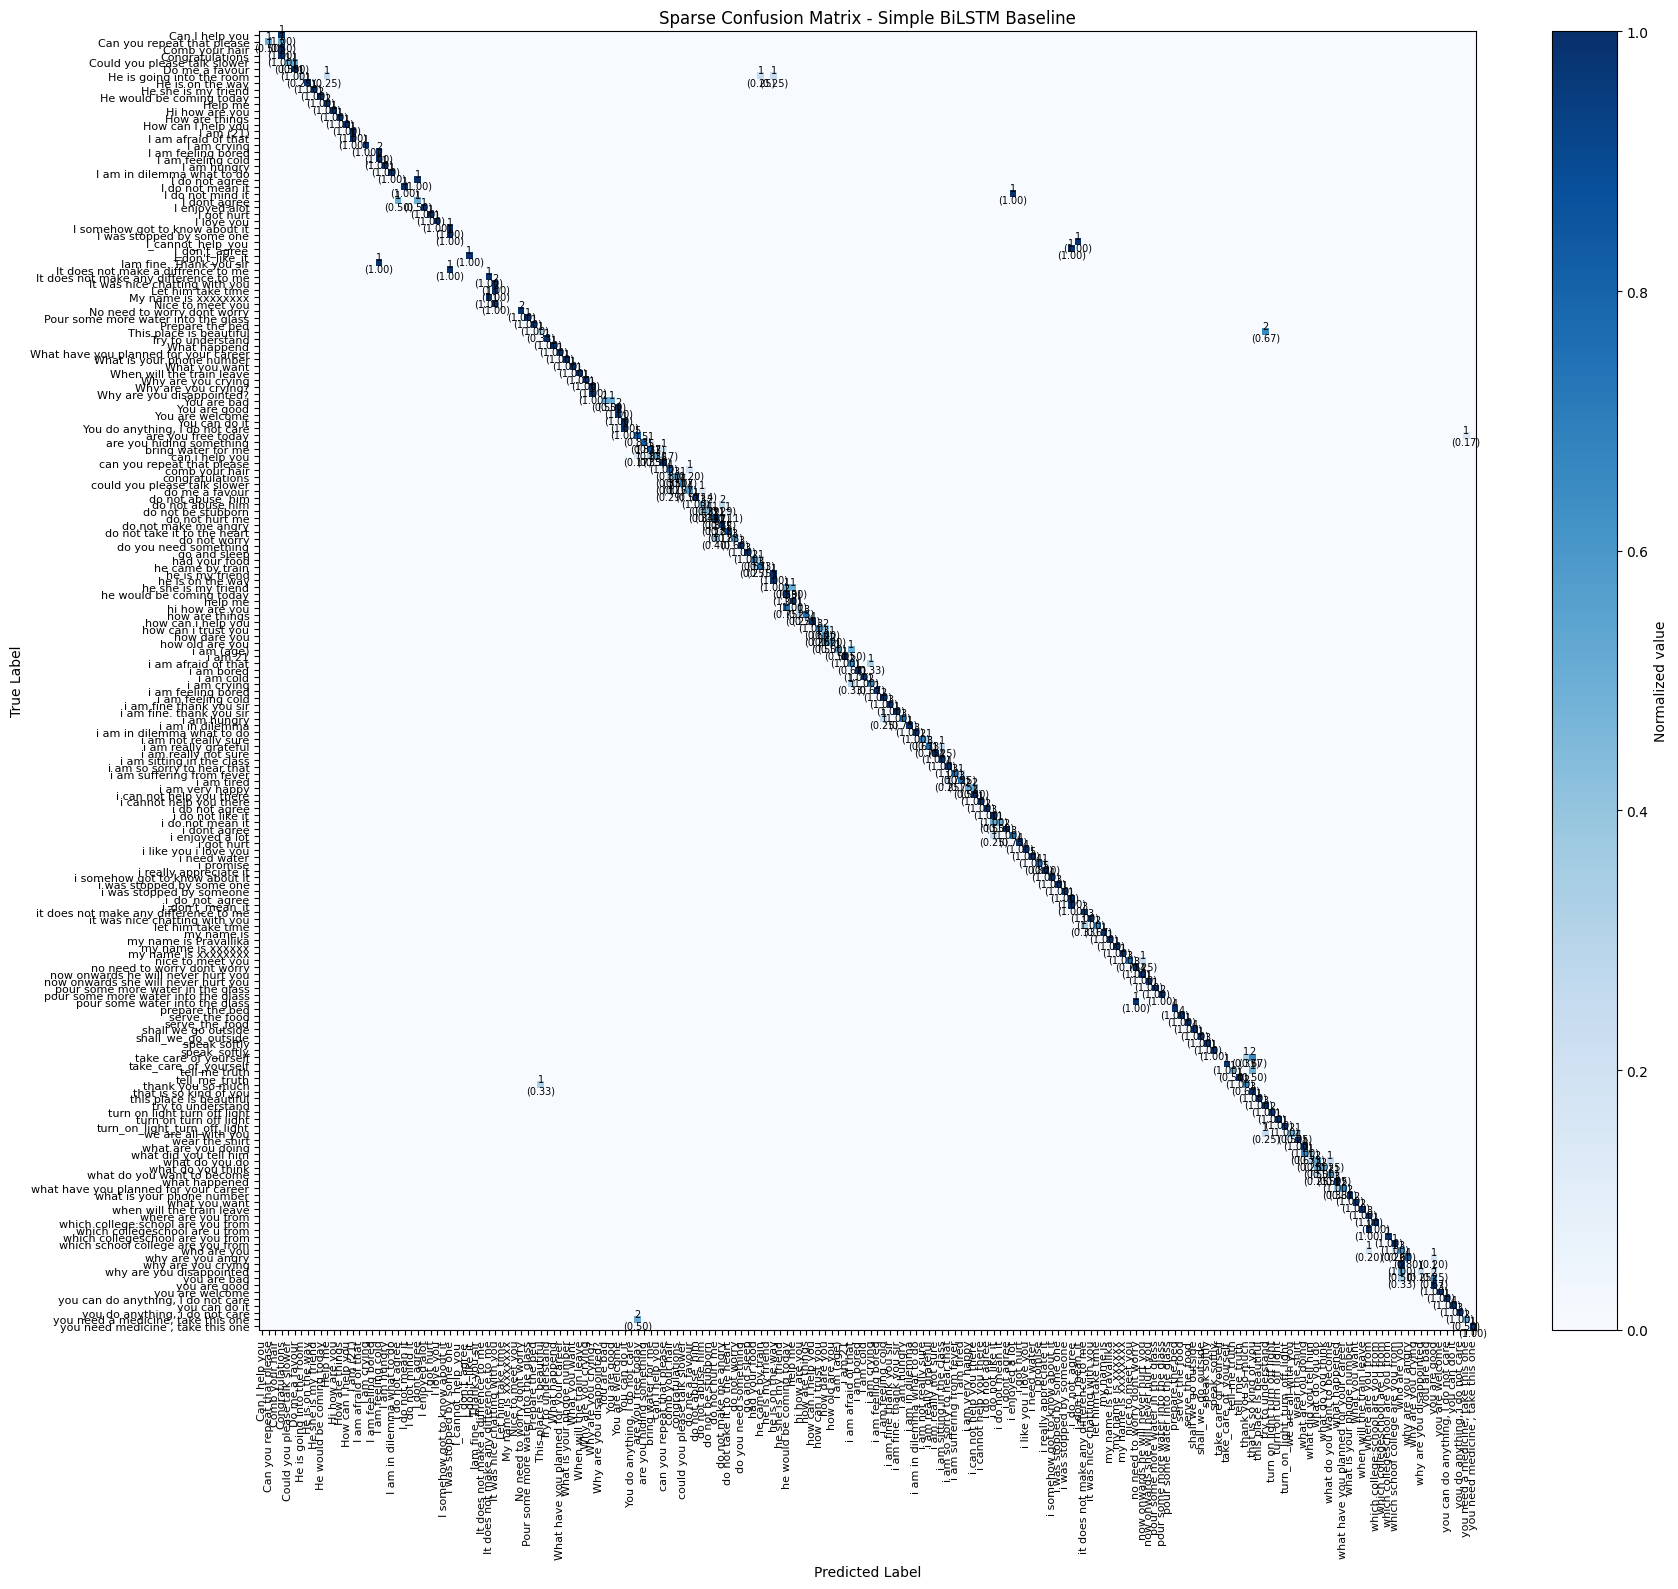

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

# Optional: normalize row-wise for readability
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(18, 16))
im = ax.imshow(cm_norm, cmap="Blues", aspect="auto")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized value")

# Set ticks and labels
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=90, fontsize=8)
ax.set_yticklabels(classes, fontsize=8)

# Annotate only non-zero cells
threshold = 0.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if cm[i, j] > 0:
            text = f"{cm[i, j]}\n({cm_norm[i, j]:.2f})"
            ax.text(j, i, text, ha="center", va="center", fontsize=7, color="black")

ax.set_title("Sparse Confusion Matrix - Simple BiLSTM Baseline")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

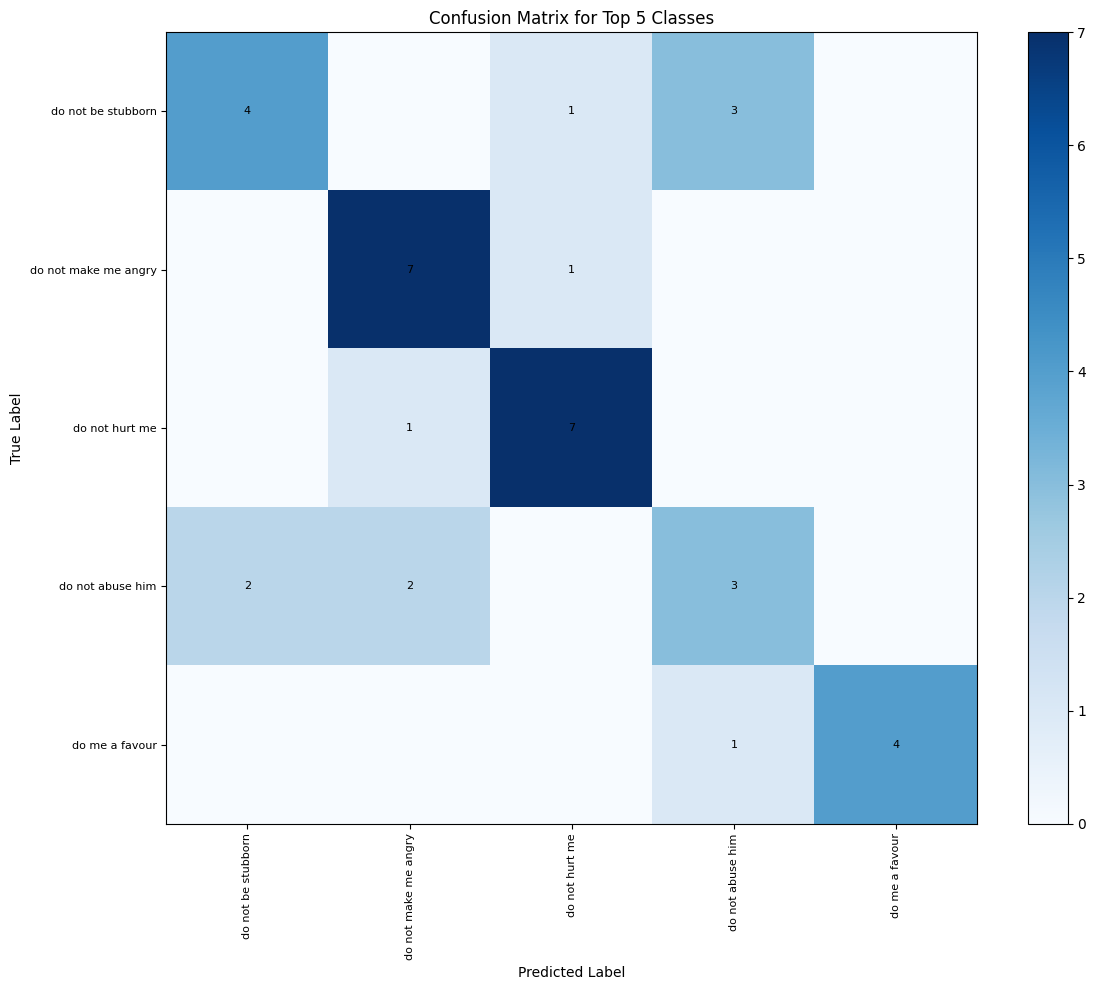

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

# Choose top N classes by frequency in validation set
N = 5
class_counts = np.sum(cm, axis=1)
top_idx = np.argsort(class_counts)[::-1][:N]

cm_small = cm[np.ix_(top_idx, top_idx)]
classes_small = np.array(classes)[top_idx]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm_small, cmap="Blues", aspect="auto")

plt.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(classes_small)))
ax.set_yticks(np.arange(len(classes_small)))
ax.set_xticklabels(classes_small, rotation=90, fontsize=8)
ax.set_yticklabels(classes_small, fontsize=8)

for i in range(cm_small.shape[0]):
    for j in range(cm_small.shape[1]):
        if cm_small[i, j] > 0:
            ax.text(j, i, str(cm_small[i, j]), ha="center", va="center", fontsize=8)

ax.set_title(f"Confusion Matrix for Top {N} Classes")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Prediction probabilities and labels for the whole validation set
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_conf = np.max(y_prob, axis=1)

# Find correctly predicted samples
correct_idx = np.where(y_pred == y_val)[0]

# Sort correct samples by confidence in descending order
correct_sorted = correct_idx[np.argsort(y_conf[correct_idx])[::-1]]

# Take top 5 confident correct predictions
top_n = 5
selected_idx = correct_sorted[:top_n]

print(f"Showing top {len(selected_idx)} confident correct predictions:\n")

for i, idx in enumerate(selected_idx, 1):
    true_label = classes[y_val[idx]]
    pred_label = classes[y_pred[idx]]
    conf = y_conf[idx]

    print(f"Sample {i}")
    print(f"Video index     : {idx}")
    print(f"True label      : {true_label}")
    print(f"Predicted label : {pred_label}")
    print(f"Confidence      : {conf:.4f}")
    print("-" * 40)

Showing top 5 confident correct predictions:

Sample 1
Video index     : 67
True label      : do not make me angry
Predicted label : do not make me angry
Confidence      : 0.9964
----------------------------------------
Sample 2
Video index     : 94
True label      : do not make me angry
Predicted label : do not make me angry
Confidence      : 0.9949
----------------------------------------
Sample 3
Video index     : 13
True label      : comb your hair
Predicted label : comb your hair
Confidence      : 0.9915
----------------------------------------
Sample 4
Video index     : 139
True label      : i enjoyed a lot
Predicted label : i enjoyed a lot
Confidence      : 0.9912
----------------------------------------
Sample 5
Video index     : 161
True label      : prepare the bed
Predicted label : prepare the bed
Confidence      : 0.9880
----------------------------------------


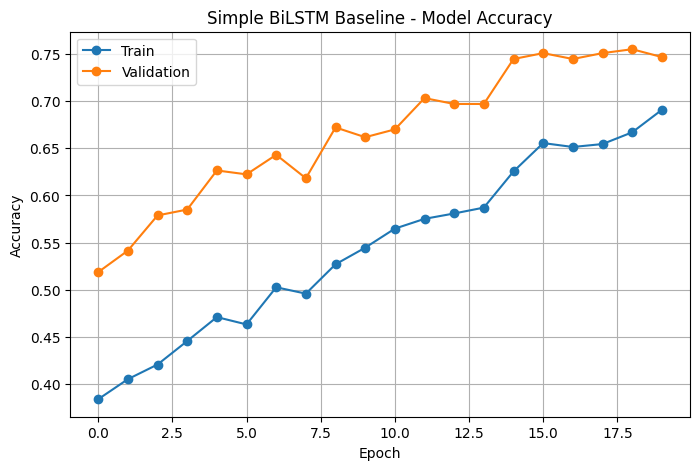

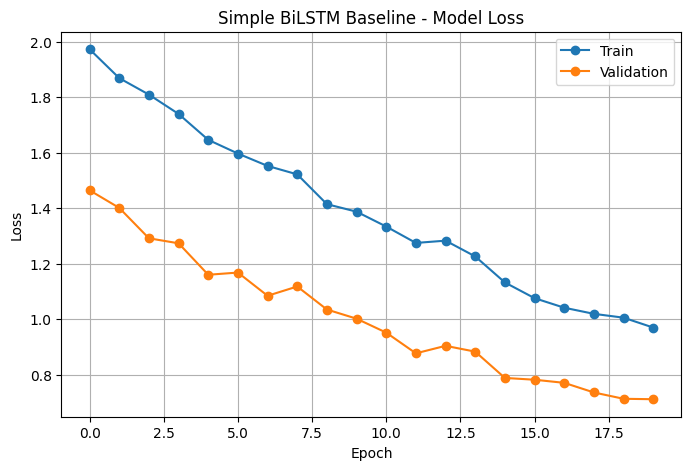

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')
plt.title('Simple BiLSTM Baseline - Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')
plt.title('Simple BiLSTM Baseline - Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid(True)
plt.show()